# MachinaQ — PointNet Feature Classifier
Kernel: **StepAnalyze (Python 3.11)**  |  Project: **MachinaQ**

In [1]:
import sys
from pathlib import Path

# Add project root to path
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Project root:", ROOT)

Project root: E:\AiTools\AIModel_StepAnalyze


## 1. Verify environment

In [2]:
import torch
import numpy as np
from OCC.Core.BRep import BRep_Builder
from OCC.Core.BRepPrimAPI import BRepPrimAPI_MakeCylinder

print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
print(f"NumPy {np.__version__}")
print("pythonocc-core: OK")

PyTorch 2.10.0  |  CUDA: True
NumPy 2.4.3
pythonocc-core: OK


## 2. Parse STEP files and inspect features

In [20]:
from src.parser import StepTextParser

STEP_DIR = ROOT / "nist_sfa"
step_files = sorted(STEP_DIR.glob("nist_*.stp"))
print(f"Found {len(step_files)} STEP files")

# Parse one file and inspect
parser = StepTextParser()
parser.parse_file(str(step_files[0]))

holes = parser.features.holes
print(f"\n{step_files[0].name}: {len(holes)} holes")
for h in holes[:5]:
    print(f"  ID={h.get('id','?')}  radius={h.get('radius','?'):.3f} mm")

Found 17 STEP files

nist_ctc_01_asme1_ap242-e1.stp: 57 holes
  ID=3509  radius=12.500 mm
  ID=3510  radius=12.500 mm
  ID=3511  radius=50.000 mm
  ID=3512  radius=50.000 mm
  ID=3513  radius=50.000 mm


## 3. Dataset generation

In [21]:
from src.train import PointCloudDataset

dataset = PointCloudDataset(
    step_files=[str(f) for f in step_files],
    num_points=1024,
    num_samples=3
)

print(f"Dataset size: {len(dataset)} samples")

pc, label = dataset[0]
print(f"Point cloud shape: {pc.shape}  |  label: {label.item()}")

Dataset size: 6012 samples
Point cloud shape: torch.Size([3, 1024])  |  label: 0


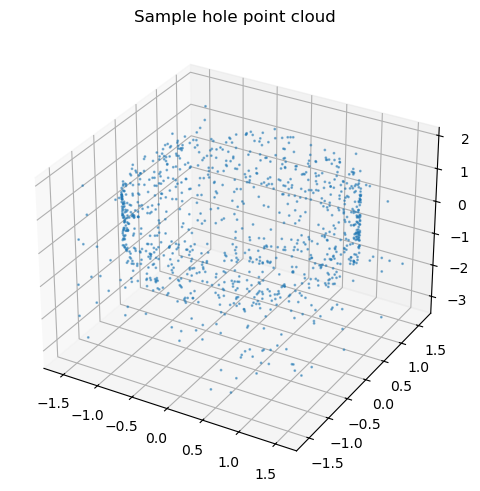

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

pc_np = pc.numpy().T  # (1024, 3)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pc_np[:, 0], pc_np[:, 1], pc_np[:, 2], s=1, alpha=0.5)
ax.set_title("MachinaQ — Sample hole point cloud")
plt.tight_layout()
plt.show()

## 4. Model architecture

In [23]:
from models.pointnet import PointNet

model = PointNet(num_classes=5)
print(model)

# Count parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {total:,}")
print(f"Trainable params: {trainable:,}")

PointNet(
  (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
  (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total params:     798,085
Trainable params: 798,085


## 5. Train

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

EPOCHS     = 10
BATCH_SIZE = 32
LR         = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

loader    = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
model     = PointNet(num_classes=5).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history = {"loss": [], "acc": []}

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for pcs, labels in loader:
        pcs, labels = pcs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(pcs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    avg_loss = total_loss / len(loader)
    acc      = 100 * correct / total
    history["loss"].append(avg_loss)
    history["acc"].append(acc)
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  loss={avg_loss:.4f}  acc={acc:.2f}%")

print("\nTraining complete.")

Device: cuda


NameError: name 'dataset' is not defined

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history["loss"], marker="o"); ax1.set_title("Loss"); ax1.set_xlabel("Epoch")
ax2.plot(history["acc"],  marker="o"); ax2.set_title("Accuracy (%)"); ax2.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 6. Save model

In [ ]:
save_path = ROOT / "models" / "machinaq_pointnet.pth"
torch.save(model.state_dict(), save_path)
print("Saved:", save_path)

## 7. Inference on a single STEP file (using pythonocc-core)

In [ ]:
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.IFSelect import IFSelect_RetDone

test_file = str(step_files[0])
reader = STEPControl_Reader()
status = reader.ReadFile(test_file)

if status == IFSelect_RetDone:
    reader.TransferRoots()
    shape = reader.OneShape()
    print("Loaded shape type:", shape.ShapeType())
else:
    print("Failed to read STEP file")

In [ ]:
from src.parser import StepTextParser

model.eval()
feature_names = ["hole", "boss", "slot", "thread", "drill"]

parser = StepTextParser()
parser.parse_file(test_file)

print(f"Detected {len(parser.features.holes)} holes — running classifier on each:")
for hole in parser.features.holes[:5]:
    from src.train import PointCloudDataset
    tmp = PointCloudDataset.__new__(PointCloudDataset)
    tmp.num_points = 1024
    pc_np = tmp._generate_hole_point_cloud(hole)
    pc_t  = torch.tensor(pc_np.tolist(), dtype=torch.float32).T.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(pc_t).argmax(1).item()
    print(f"  radius={hole.get('radius',0):.2f} mm  →  predicted: {feature_names[pred]}")